In [863]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [864]:
# Load the dataset
df = pd.read_csv("japan_birth_statistics_1899_2024.csv")

# Display the first 5 rows
df.head()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,2024,686173,351451,334722,5.7,105.0,1.15
1,2023,727288,372603,354685,6.0,105.1,1.20
2,2022,770759,395257,375502,6.3,105.3,1.26
3,2021,811622,415903,395719,6.6,105.1,1.30
4,2020,840835,430713,410122,6.8,105.0,1.33


In [865]:
df.tail()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
118,1903,1489816,763806,726010,32.7,105.2,NaN
119,1902,1510835,773296,737539,33.6,104.8,NaN
120,1901,1501591,769494,732097,33.9,105.1,NaN
121,1900,1420534,727916,692618,32.4,105.1,NaN
122,1899,1386981,713442,673539,32.0,105.9,NaN


# Data Inspection

In [866]:
# Check shape of dataset
print("Shape of dataset:", df.shape)

# Show column names
print("\nColumns:")
print(df.columns.tolist())

# Display first 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

Shape of dataset: (123, 7)

Columns:
['year', 'total_births', 'male_births', 'female_births', 'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate']

First 10 rows:
   year  total_births  male_births  female_births  crude_birth_rate  \
0  2024        686173       351451         334722               5.7   
1  2023        727288       372603         354685               6.0   
2  2022        770759       395257         375502               6.3   
3  2021        811622       415903         395719               6.6   
4  2020        840835       430713         410122               6.8   
5  2019        865239       443430         421809               7.0   
6  2018        918400       470851         447549               7.4   
7  2017        946146       484478         461668               7.6   
8  2016        977242       502012         475230               7.8   
9  2015       1005721       515468         490253               8.0   

   sex_ratio_at_birth  total_fertility_rat

In [867]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  123 non-null    int64  
 1   total_births          123 non-null    int64  
 2   male_births           123 non-null    int64  
 3   female_births         123 non-null    int64  
 4   crude_birth_rate      123 non-null    float64
 5   sex_ratio_at_birth    123 non-null    float64
 6   total_fertility_rate  78 non-null     float64
dtypes: float64(3), int64(4)
memory usage: 6.9 KB


In [868]:
df.describe()

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
count,123.000000,1.230000e+02,1.230000e+02,1.230000e+02,123.000000,123.00000,78.000000
mean,1961.902439,1.611732e+06,8.265919e+05,7.851403e+05,20.701626,105.30813,1.851667
std,36.870268,4.454999e+05,2.281287e+05,2.174267e+05,10.579326,0.85532,0.696202
min,1899.000000,6.861730e+05,3.514510e+05,3.347220e+05,5.700000,102.70000,1.150000
25%,1929.500000,1.207772e+06,6.209645e+05,5.868075e+05,9.750000,104.90000,1.390000
50%,1963.000000,1.653469e+06,8.487330e+05,8.047360e+05,18.600000,105.30000,1.705000
75%,1993.500000,1.980095e+06,1.010740e+06,9.666640e+05,32.350000,105.80000,2.050000
max,2024.000000,2.696638e+06,1.380008e+06,1.316630e+06,36.200000,108.70000,4.540000


In [869]:
df.isnull().sum()

year                     0
total_births             0
male_births              0
female_births            0
crude_birth_rate         0
sex_ratio_at_birth       0
total_fertility_rate    45
dtype: int64

In [870]:
duplicates = df.duplicated().sum()
duplicates

0

In [871]:
# Check if male_births + female_births equals total_births
df["birth_difference"] = (df["male_births"] + df["female_births"]) - df["total_births"]

print("Rows with inconsistencies in total_births:")
print(df[df["birth_difference"] != 0][["year", "total_births", "male_births", "female_births", "birth_difference"]])

Rows with inconsistencies in total_births:
    year  total_births  male_births  female_births  birth_difference
86  1935       2190704      1122867        1067836                -1
91  1930       2085101      1069551        1015549                -1
95  1926       2104405      1081793        1022611                -1


# Data Cleaning

In [872]:
# Make a copy of the original dataset
clean_df = df.copy()

# Sort by year first before interpolation
clean_df = clean_df.sort_values("year").reset_index(drop=True)

# Fill missing values in total_fertility_rate using interpolation
clean_df["total_fertility_rate"] = (
    clean_df["total_fertility_rate"]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

clean_df.isnull().sum()

year                    0
total_births            0
male_births             0
female_births           0
crude_birth_rate        0
sex_ratio_at_birth      0
total_fertility_rate    0
birth_difference        0
dtype: int64

In [873]:
# Recalculate total_births from male_births + female_births
clean_df["total_births"] = clean_df["male_births"] + clean_df["female_births"]

# Recheck consistency
clean_df["birth_difference"] = (clean_df["male_births"] + clean_df["female_births"]) - clean_df["total_births"]

print("Remaining inconsistencies after correction:")
print(clean_df[clean_df["birth_difference"] != 0][["year", "total_births", "male_births", "female_births", "birth_difference"]])

Remaining inconsistencies after correction:
Empty DataFrame
Columns: [year, total_births, male_births, female_births, birth_difference]
Index: []


In [874]:
# Drop helper column after checking
clean_df = clean_df.drop(columns=["birth_difference"])


# drop rows before 1970 (Baby Boom era, World War, etc. may skew the data)
clean_df = clean_df[clean_df["year"] >= 1947].copy()

# Data Preparation

In [875]:
# Features and target
X = clean_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y = clean_df["total_births"]

In [876]:
# Create train and test sets based on year
train_df = clean_df[clean_df["year"] <= 2013]
test_df = clean_df[clean_df["year"] > 2013]

X_train = train_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y_train = train_df["total_births"]

X_test = test_df[["year", "crude_birth_rate", "sex_ratio_at_birth", "total_fertility_rate"]]
y_test = test_df["total_births"]

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (67, 4)
Testing set size: (11, 4)


# Model Training

In [877]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

# Visualization

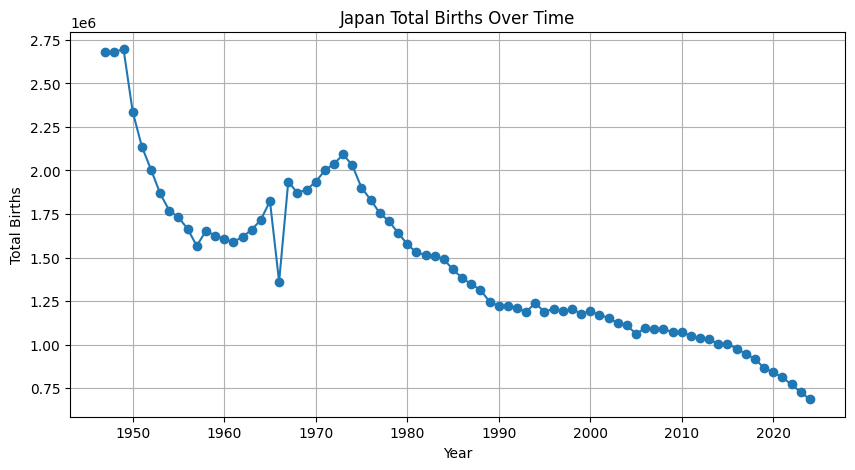

In [878]:
plt.figure(figsize=(10, 5))
plt.plot(clean_df["year"], clean_df["total_births"], marker="o")
plt.title("Japan Total Births Over Time")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.grid(True)
plt.show()

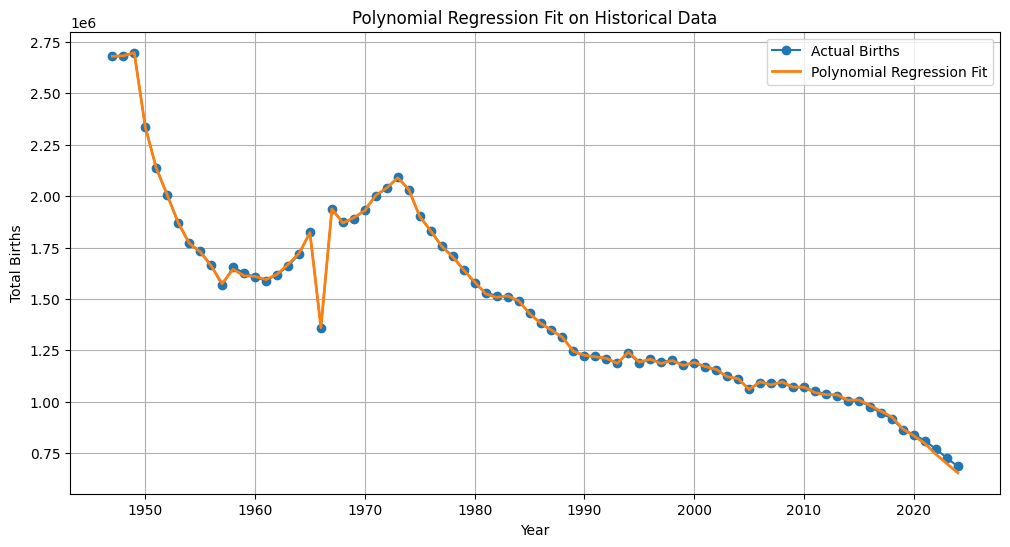

In [879]:
# Predict for all known years in clean_df
all_pred_poly = poly_model.predict(clean_df[[
    "year",
    "crude_birth_rate",
    "sex_ratio_at_birth",
    "total_fertility_rate"
]])

plt.figure(figsize=(12, 6))
plt.plot(clean_df["year"], clean_df["total_births"], marker="o", label="Actual Births")
plt.plot(clean_df["year"], all_pred_poly, linewidth=2, label="Polynomial Regression Fit")

plt.title("Polynomial Regression Fit on Historical Data")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.legend()
plt.grid(True)
plt.show()

In [880]:
results_df = pd.DataFrame({
    "year": test_df["year"],
    "actual_total_births": y_test,
    "predicted_total_births": y_pred_poly
})

results_df

,year,actual_total_births,predicted_total_births
112,2014,1003609,1.007670e+06
113,2015,1005721,1.009192e+06
114,2016,977242,9.822170e+05
115,2017,946146,9.548138e+05
116,2018,918400,9.265630e+05
117,2019,865239,8.678300e+05
118,2020,840835,8.350552e+05
119,2021,811622,7.979411e+05
120,2022,770759,7.457474e+05
121,2023,727288,6.996991e+05


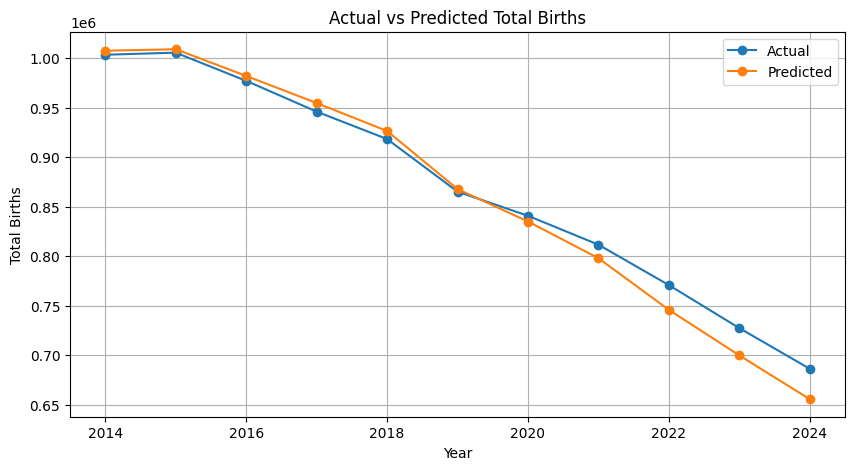

In [881]:
plt.figure(figsize=(10, 5))
plt.plot(results_df["year"], results_df["actual_total_births"], marker="o", label="Actual")
plt.plot(results_df["year"], results_df["predicted_total_births"], marker="o", label="Predicted")
plt.title("Actual vs Predicted Total Births")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.legend()
plt.grid(True)
plt.show()

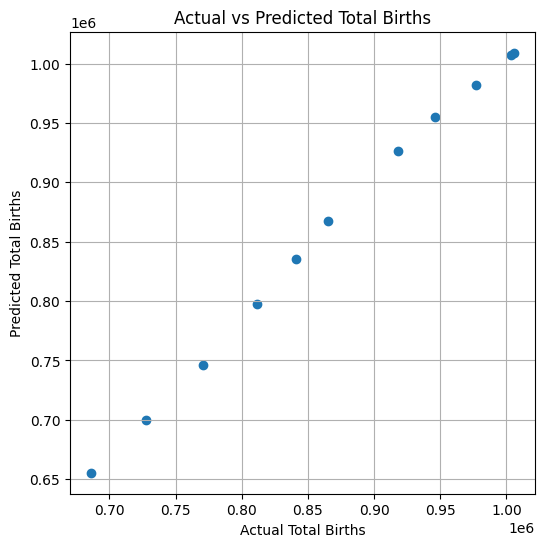

In [882]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly)
plt.title("Actual vs Predicted Total Births")
plt.xlabel("Actual Total Births")
plt.ylabel("Predicted Total Births")
plt.grid(True)
plt.show()

# Metrics

In [883]:
# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Performance:")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"R² Score: {r2:.4f}")

Polynomial Regression Performance:
MAE: 12,248.98
MSE: 250,412,794.53
R² Score: 0.9778


# Prediction up to 2030

   year  crude_birth_rate  sex_ratio_at_birth  total_fertility_rate  \
0  2025              5.29              105.26                  1.04   
1  2026              5.00              105.28                  0.99   
2  2027              4.70              105.31                  0.93   
3  2028              4.38              105.35                  0.88   
4  2029              4.05              105.38                  0.81   
5  2030              3.70              105.43                  0.75   

   predicted_total_births  
0                  574039  
1                  527470  
2                  480558  
3                  434000  
4                  388680  
5                  345709  


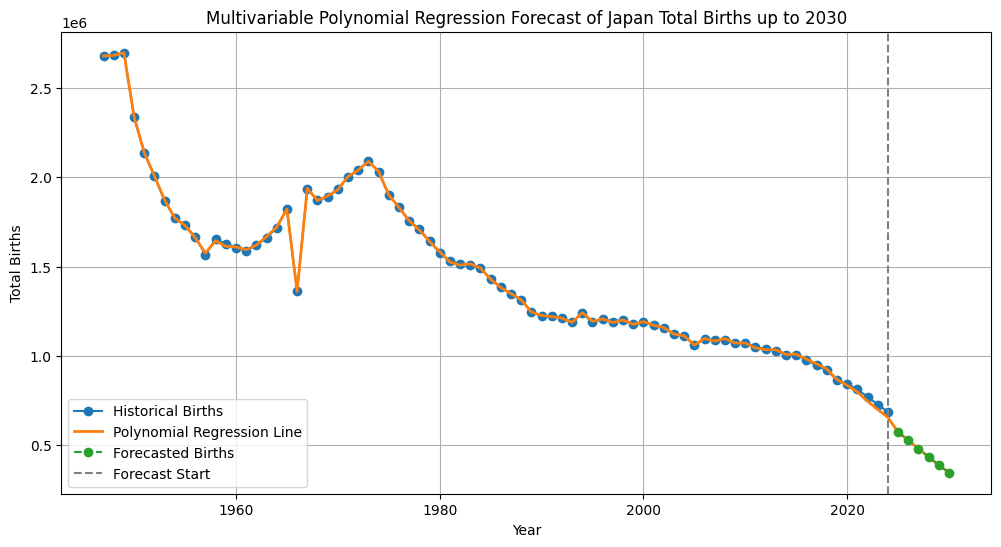

In [884]:


future_years = pd.DataFrame({
    "year": [2025, 2026, 2027, 2028, 2029, 2030]
})


birth_rate_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)
birth_rate_model.fit(clean_df[["year"]], clean_df["crude_birth_rate"])
future_years["crude_birth_rate"] = birth_rate_model.predict(future_years[["year"]])

sex_ratio_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)
sex_ratio_model.fit(clean_df[["year"]], clean_df["sex_ratio_at_birth"])
future_years["sex_ratio_at_birth"] = sex_ratio_model.predict(future_years[["year"]])

fertility_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)
fertility_model.fit(clean_df[["year"]], clean_df["total_fertility_rate"])
future_years["total_fertility_rate"] = fertility_model.predict(future_years[["year"]])


# -----------------------------
# PREDICT FUTURE TOTAL BIRTHS
# -----------------------------
future_features = future_years[[
    "year",
    "crude_birth_rate",
    "sex_ratio_at_birth",
    "total_fertility_rate"
]]

future_years["predicted_total_births"] = poly_model.predict(future_features)

# -----------------------------
# HISTORICAL FITTED VALUES
# -----------------------------
historical_features = clean_df[[
    "year",
    "crude_birth_rate",
    "sex_ratio_at_birth",
    "total_fertility_rate"
]]

clean_df["fitted_total_births"] = poly_model.predict(historical_features)

# -----------------------------
# COMBINE HISTORICAL FIT + FUTURE FORECAST
# -----------------------------
curve_df = pd.concat([
    clean_df[["year", "fitted_total_births"]].rename(columns={"fitted_total_births": "model_births"}),
    future_years[["year", "predicted_total_births"]].rename(columns={"predicted_total_births": "model_births"})
], ignore_index=True)

curve_df = curve_df.sort_values("year")

# -----------------------------
# ROUND FOR TABLE DISPLAY
# -----------------------------
future_years["crude_birth_rate"] = future_years["crude_birth_rate"].round(2)
future_years["sex_ratio_at_birth"] = future_years["sex_ratio_at_birth"].round(2)
future_years["total_fertility_rate"] = future_years["total_fertility_rate"].round(2)
future_years["predicted_total_births"] = future_years["predicted_total_births"].round(0).astype(int)

print(future_years)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12, 6))

# Actual historical births
plt.plot(clean_df["year"], clean_df["total_births"], marker="o", label="Historical Births")

# Polynomial regression fitted + forecast line
plt.plot(curve_df["year"], curve_df["model_births"], linewidth=2, label="Polynomial Regression Line")

# Forecast points only
plt.plot(future_years["year"], future_years["predicted_total_births"], marker="o", linestyle="--", label="Forecasted Births")

plt.axvline(x=2024, linestyle="--", color="gray", label="Forecast Start")
plt.title("Multivariable Polynomial Regression Forecast of Japan Total Births up to 2030")
plt.xlabel("Year")
plt.ylabel("Total Births")
plt.legend()
plt.grid(True)
plt.show()

In [885]:
future_features = future_years[[
    "year",
    "crude_birth_rate",
    "sex_ratio_at_birth",
    "total_fertility_rate"
]]

future_years["predicted_total_births"] = poly_model.predict(future_features)

future_years

,year,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate,predicted_total_births
0,2025,5.29,105.26,1.04,573655.073009
1,2026,5.00,105.28,0.99,527616.705456
2,2027,4.70,105.31,0.93,481208.999722
3,2028,4.38,105.35,0.88,433349.741001
4,2029,4.05,105.38,0.81,390872.125912
5,2030,3.70,105.43,0.75,345006.721855
